saved /content/Figure3_data_overview.png


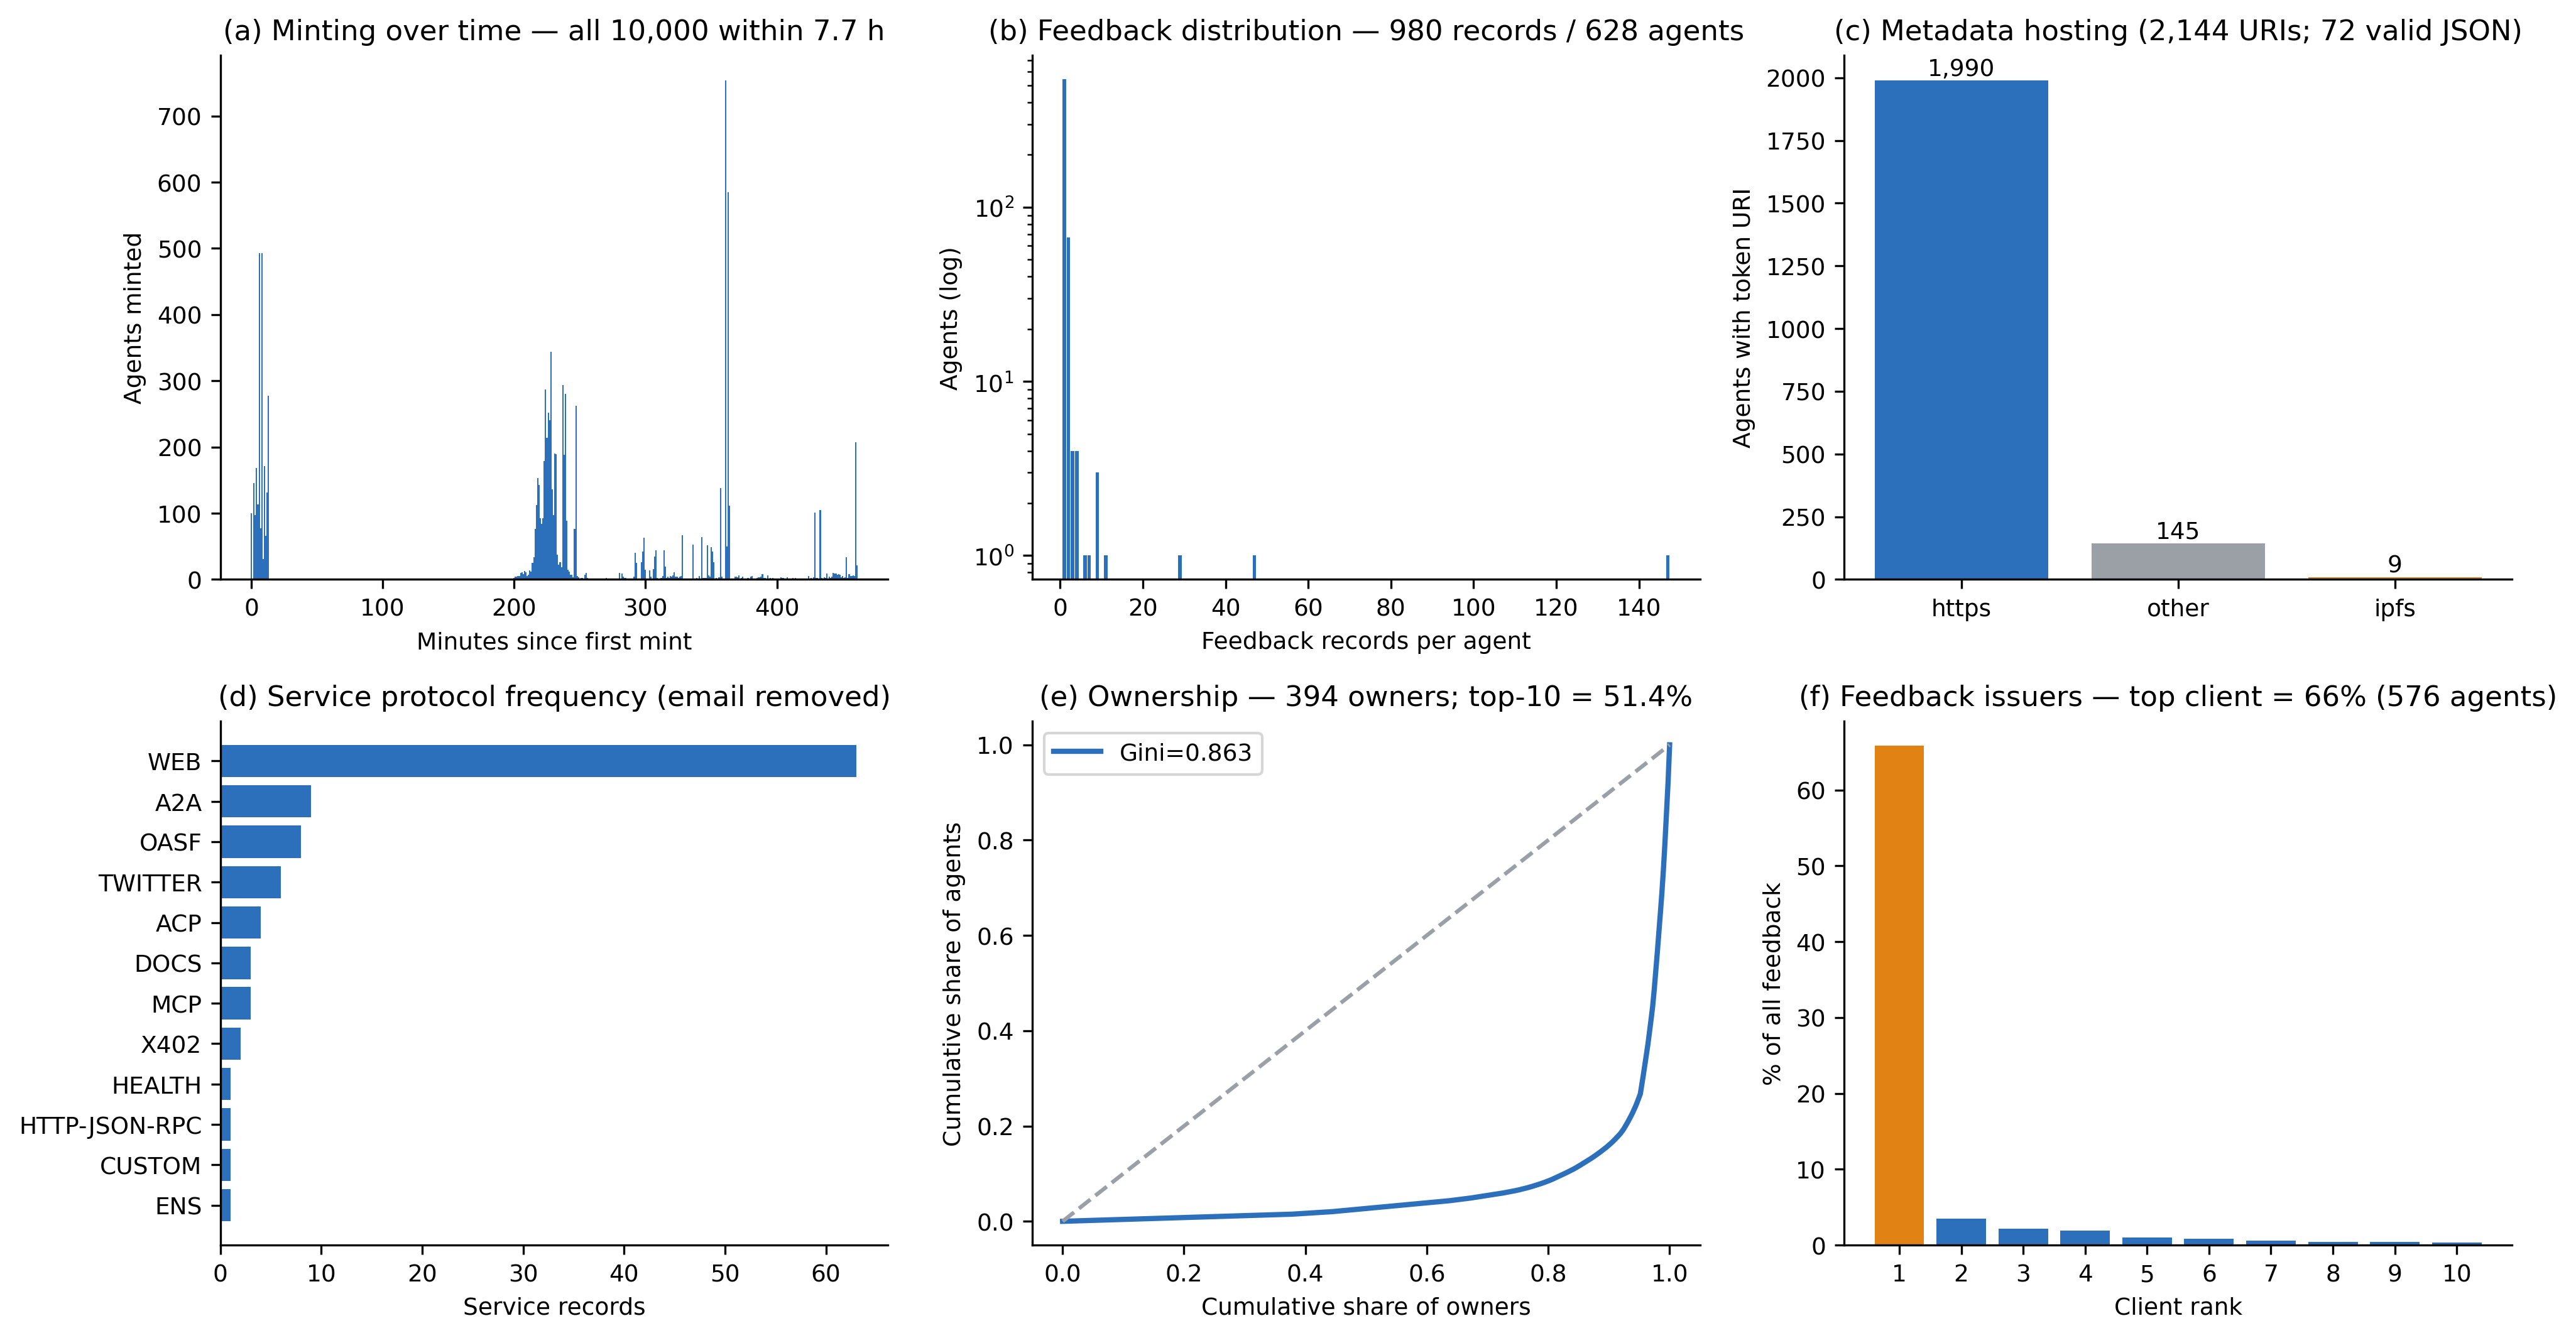

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
#!/usr/bin/env python3
"""Figure 3: Data overview — Colab version (reads CSVs from /content)."""
import pandas as pd, numpy as np
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt

DATA_DIR = "/content"                       # uploaded files live here in Colab
OUT      = "/content/Figure3_data_overview.png"

ac = pd.read_csv(f"{DATA_DIR}/agents_core.csv")
md = pd.read_csv(f"{DATA_DIR}/agent_metadata.csv")
sv = pd.read_csv(f"{DATA_DIR}/agent_services.csv")
fb = pd.read_csv(f"{DATA_DIR}/agent_feedback_records.csv")

BLUE = "#2c6fbb"; GREY = "#9aa0a6"; ORANGE = "#e08214"
plt.rcParams.update({"font.size": 9, "axes.spines.top": False, "axes.spines.right": False})

def gini(v):
    v = np.sort(np.asarray(v, float)); n = len(v); c = np.cumsum(v)
    return (n + 1 - 2 * np.sum(c) / c[-1]) / n

# ---- derive every number from the data ----
n_agents     = len(ac)
n_uri        = int(ac.token_uri.notna().sum())
n_json       = len(md)
fb_total     = len(fb)
fb_agents    = fb.agent_id.nunique()
ow           = ac.owner_wallet.str.lower().value_counts()
n_owners     = len(ow)
top10_share  = 100 * ow.head(10).sum() / n_agents
owner_gini   = gini(ow.values)
cl           = fb.client_address.value_counts()
top_client   = cl.index[0]
top_share    = 100 * cl.iloc[0] / fb_total
top_client_n_agents = fb[fb.client_address == top_client].agent_id.nunique()

fig, axs = plt.subplots(2, 3, figsize=(13.5, 7.2)); axs = axs.ravel()

# (a) minting over time
ac["mint_ts"] = pd.to_datetime(ac.mint_timestamp, utc=True, errors="coerce")
tmin = ac.mint_ts.min().floor("min")
mins = ((ac.mint_ts - tmin).dt.total_seconds() // 60).astype(int)
vc = mins.value_counts().sort_index()
dur = (ac.mint_ts.max() - ac.mint_ts.min()).total_seconds() / 3600
axs[0].bar(vc.index, vc.values, width=1.0, color=BLUE)
axs[0].set_xlabel("Minutes since first mint"); axs[0].set_ylabel("Agents minted")
axs[0].set_title(f"(a) Minting over time — all {n_agents:,} within {dur:.1f} h")

# (b) feedback records per agent
pa = fb.groupby("agent_id").size()
axs[1].hist(pa.values, bins=range(1, pa.max() + 2), color=BLUE, align="left", rwidth=0.85)
axs[1].set_yscale("log")
axs[1].set_xlabel("Feedback records per agent"); axs[1].set_ylabel("Agents (log)")
axs[1].set_title(f"(b) Feedback distribution — {fb_total:,} records / {fb_agents:,} agents")

# (c) metadata hosting types
host = ac.metadata_hosting_type.value_counts()
axs[2].bar(host.index, host.values, color=[BLUE, GREY, ORANGE][:len(host)])
for i, v in enumerate(host.values):
    axs[2].text(i, v, f"{v:,}", ha="center", va="bottom")
axs[2].set_ylabel("Agents with token URI")
axs[2].set_title(f"(c) Metadata hosting ({n_uri:,} URIs; {n_json:,} valid JSON)")

# (d) service-protocol frequency (email removed, names normalized)
sv["n"] = sv.service_name.astype(str).str.strip().str.upper().replace({"NAN": None})
sf = sv[~sv.n.isin([None, "EMAIL"])].n.value_counts()
axs[3].barh(sf.index[::-1], sf.values[::-1], color=BLUE)
axs[3].set_xlabel("Service records"); axs[3].set_title("(d) Service protocol frequency (email removed)")

# (e) ownership concentration
x = np.sort(ow.values); cum = np.cumsum(x) / x.sum(); p = np.arange(1, len(x) + 1) / len(x)
axs[4].plot(np.r_[0, p], np.r_[0, cum], color=BLUE, lw=2, label=f"Gini={owner_gini:.3f}")
axs[4].plot([0, 1], [0, 1], "--", color=GREY); axs[4].legend(loc="upper left")
axs[4].set_xlabel("Cumulative share of owners"); axs[4].set_ylabel("Cumulative share of agents")
axs[4].set_title(f"(e) Ownership — {n_owners:,} owners; top-10 = {top10_share:.1f}%")

# (f) feedback-issuer concentration
share = cl.values / cl.sum() * 100
top = share[:10]
axs[5].bar(range(len(top)), top, color=[ORANGE] + [BLUE] * (len(top) - 1))
axs[5].set_xlabel("Client rank"); axs[5].set_ylabel("% of all feedback")
axs[5].set_title(f"(f) Feedback issuers — top client = {top_share:.0f}% ({top_client_n_agents:,} agents)")
axs[5].set_xticks(range(len(top))); axs[5].set_xticklabels([str(i + 1) for i in range(len(top))])

fig.tight_layout()
fig.savefig(OUT, dpi=300, bbox_inches="tight")
print("saved", OUT)

# show inline + download to your computer
from IPython.display import Image, display
display(Image(OUT))
from google.colab import files
files.download(OUT)